In [1]:
%%capture
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

In [2]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
names = open('names.txt').read().splitlines()

# tokenizer
vocab = sorted(set(''.join(names) + '.'))
vocab_size = len(vocab)
stoi = {v:k for k, v in enumerate(vocab)}
itos = {v:k for k, v in stoi.items()}

def decode(seq: list[int]) -> str:
    return ''.join([itos[i] for i in seq])

def encode(name: str) -> list[int]:
    return [stoi[s] for s in name]

In [4]:
block_size = 3

X = []
Y = []

for name in names:
    context = [0] * block_size
    for ch in name + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(f"{context} -> {ix}")
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

train_size = int(.8 * X.shape[0])
Xtr, Xts = X[:train_size], X[train_size:]
Ytr, Yts = Y[:train_size], Y[train_size:]

In [5]:
from torch.utils.data import Dataset, TensorDataset, DataLoader

# class NamesDataset(Dataset):
#     def __init__(self, X, Y):
#         self.X = X
#         self.Y = Y

#     def __getitem__(self, idx):
#         return self.X[idx], self.Y[idx]

#     def __len__(self):
#         return self.X.shape[0]

Dtr = TensorDataset(Xtr, Ytr)
Dts = TensorDataset(Xts, Yts)

In [6]:
DLtr = DataLoader(Dtr, batch_size=32, shuffle=True, drop_last=True)
DLts = DataLoader(Dts, batch_size=32, shuffle=False, drop_last=False)

In [7]:
class NameGenerator(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_hidden):
        super().__init__()
        self.E = nn.Embedding(vocab_size, n_embd)
        self.lin1 = nn.Linear(block_size * n_embd, n_hidden)
        self.tanh = nn.Tanh()
        self.out = nn.Linear(n_hidden, vocab_size)

        torch.nn.init.xavier_uniform_(self.lin1.weight)


    def forward(self, x):
        # x: (B, T)
        xemb = self.E(x) # x shape: (B, T, C) or (batch_size, block_size, n_embd)
        # print(f"xemb shape: {xemb.shape}")
        B, T, C = xemb.shape
        xflat = xemb.view(B, T * C) # (B, T * C) or (batch_size, block_size * n_embd)
        # print(f"xflat shape: {xflat.shape}")
        hpreact = self.lin1(xflat)
        h = self.tanh(hpreact)
        logits = self.out(h)
        return logits

n_embd = 2
model = NameGenerator(vocab_size, n_embd, block_size=3, n_hidden=50).to(device)
model2 = NameGenerator(vocab_size, n_embd=32, block_size=3, n_hidden=150).to(device)
optimizer = torch.optim.Adam(model.parameters())
optimizer2 = torch.optim.Adam(model2.parameters())

In [8]:
def plot_embedding():

    w = model.E.weight.cpu().detach().numpy()

    plt.figure(figsize=(8, 8))
    plt.scatter(w[:, 0], w[:, 1], s=200)

    for i in range(27):
        char = itos[i]
        plt.text(w[i][0], w[i][1], char, ha='center', va='center', color='white')
    plt.show()

In [9]:
# model hyperparameters
n_embd = 2
n_hidden = 50

E = torch.randn(vocab_size, n_embd)
W1 = torch.randn(block_size * n_embd, n_hidden) / ((block_size * n_embd) ** 0.5)
b1 = torch.randn(n_hidden) / ((block_size * n_embd) ** 0.5)
W2 = torch.randn(n_hidden, vocab_size) * 0.01
b2 = torch.randn(vocab_size) * 0

params = [E, W1, b1, W2, b2]

for param in params:
    param.requires_grad = True

In [10]:
from IPython.display import clear_output

In [11]:
@torch.no_grad()
def evaluate(model):
    model.eval()

    epoch_loss = 0.0
    for x, y in DLts:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        epoch_loss += loss.item()
    epoch_loss /= len(DLts)

    return epoch_loss

In [12]:
def train(model, optimizer, n_epoch = 10):
    torch.manual_seed(42)
    lossi = []

    for epoch in range(n_epoch):
        model.train()
        epoch_loss = 0.0
        for x, y in DLtr:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y)

            # for param in model.parameters():
            #     param.grad = None
            optimizer.zero_grad()

            loss.backward()

            # for param in model.parameters():
            #     param.data -= 0.01 * param.grad
            optimizer.step()

            epoch_loss += loss.item()
            lossi.append(loss.item())
        epoch_loss /= len(DLtr)
        eval_loss = evaluate(model)
        print(f"Epoch {epoch+1} | Train Loss: {epoch_loss:.3f} | Eval Loss: {eval_loss:.3f}")

    return lossi
        # plot_embedding()
        # clear_output(wait=True)

In [13]:
lossi = train(model, optimizer)

Epoch 1 | Train Loss: 2.506 | Eval Loss: 2.590
Epoch 2 | Train Loss: 2.384 | Eval Loss: 2.540
Epoch 3 | Train Loss: 2.336 | Eval Loss: 2.521
Epoch 4 | Train Loss: 2.310 | Eval Loss: 2.507
Epoch 5 | Train Loss: 2.295 | Eval Loss: 2.501
Epoch 6 | Train Loss: 2.284 | Eval Loss: 2.514
Epoch 7 | Train Loss: 2.275 | Eval Loss: 2.490
Epoch 8 | Train Loss: 2.268 | Eval Loss: 2.481
Epoch 9 | Train Loss: 2.262 | Eval Loss: 2.491
Epoch 10 | Train Loss: 2.255 | Eval Loss: 2.492


In [14]:
lossi = train(model2, optimizer2)

Epoch 1 | Train Loss: 2.237 | Eval Loss: 2.413
Epoch 2 | Train Loss: 2.133 | Eval Loss: 2.381
Epoch 3 | Train Loss: 2.101 | Eval Loss: 2.366
Epoch 4 | Train Loss: 2.081 | Eval Loss: 2.349
Epoch 5 | Train Loss: 2.069 | Eval Loss: 2.361
Epoch 6 | Train Loss: 2.059 | Eval Loss: 2.375
Epoch 7 | Train Loss: 2.050 | Eval Loss: 2.365
Epoch 8 | Train Loss: 2.044 | Eval Loss: 2.349
Epoch 9 | Train Loss: 2.040 | Eval Loss: 2.369
Epoch 10 | Train Loss: 2.034 | Eval Loss: 2.362


# **Homework**

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [16]:
names = open("names.txt").read().splitlines()


In [17]:
print("Total names:", len(names))
names[:10]

Total names: 32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [18]:
chars = sorted(list(set("".join(names))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}

vocab_size = len(stoi)
print("Vocab size:", vocab_size)

Vocab size: 27


In [19]:
import random

def build_dataset(names, block_size=3):
    X, Y = [], []

    for w in names:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    return torch.tensor(X), torch.tensor(Y)

block_size = 4

X, Y = build_dataset(names, block_size)
print(X.shape, Y.shape)

torch.Size([228146, 4]) torch.Size([228146])


In [20]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X, Y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [21]:
class MLPNameModel(nn.Module):
    def __init__(self, vocab_size, block_size, n_embd=32,
                 hidden_sizes=[128, 128, 128]):  # <-- change depth here
        super().__init__()

        self.emb = nn.Embedding(vocab_size, n_embd)

        layers = []
        input_size = block_size * n_embd

        for h in hidden_sizes:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h

        layers.append(nn.Linear(input_size, vocab_size))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        emb = self.emb(x)              # (B, block, n_embd)
        x = emb.view(emb.shape[0], -1) # flatten
        logits = self.net(x)
        return logits

# Example configuration
model = MLPNameModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=64,
    hidden_sizes=[256, 256, 256, 256],   # 4 hidden layers
).to(device)

print(model)

MLPNameModel(
  (emb): Embedding(27, 64)
  (net): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=27, bias=True)
  )
)


Epoch 1 | Loss 2.2337
Epoch 2 | Loss 2.1064
Epoch 3 | Loss 2.0560
Epoch 4 | Loss 2.0248
Epoch 5 | Loss 2.0021
Epoch 6 | Loss 1.9882
Epoch 7 | Loss 1.9736
Epoch 8 | Loss 1.9628
Epoch 9 | Loss 1.9531
Epoch 10 | Loss 1.9448
Epoch 11 | Loss 1.9384
Epoch 12 | Loss 1.9329
Epoch 13 | Loss 1.9283
Epoch 14 | Loss 1.9208
Epoch 15 | Loss 1.9166
Epoch 16 | Loss 1.9127
Epoch 17 | Loss 1.9085
Epoch 18 | Loss 1.9059
Epoch 19 | Loss 1.9027
Epoch 20 | Loss 1.9002


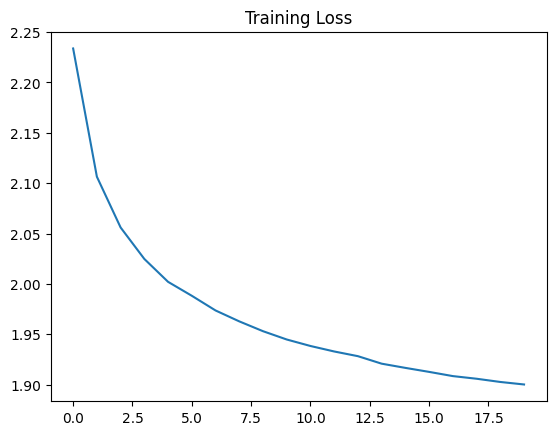

In [22]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train(model, epochs=10):
    model.train()
    losses = []

    for epoch in range(epochs):
        total = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item()

        total /= len(train_loader)
        losses.append(total)
        print(f"Epoch {epoch+1} | Loss {total:.4f}")

    plt.plot(losses)
    plt.title("Training Loss")
    plt.show()

train(model, epochs=20)

In [23]:
import torch.nn.functional as F

def generate(model, block_size, num_samples=20):
    model.eval()
    for _ in range(num_samples):
        context = [0] * block_size
        out = []

        while True:
            x = torch.tensor([context]).to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=-1)
            ix = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [ix]
            if ix == 0:
                break
            out.append(itos[ix])

        print("".join(out))

generate(model, block_size)

krisanek
virak
endry
rance
kenirishiir
fibe
livi
bryis
amusgemini
miya
diony
kunirimone
indell
vivaughn
krusetv
kahayah
trent
mikenzle
edger
dimotatiya


# **Homework again**

In [26]:
n = len(X)
n_train = int(0.9 * n)

X_train = X[:n_train]
Y_train = Y[:n_train]

X_val = X[n_train:]
Y_val = Y[n_train:]

print(X_train.shape, X_val.shape)

torch.Size([205331, 4]) torch.Size([22815, 4])


In [27]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [28]:
class MLPNameModel(nn.Module):
    def __init__(self, vocab_size, block_size, n_embd=32,
                 hidden_sizes=[256,256,256,256]):    # <--- change #layers here
        super().__init__()

        self.emb = nn.Embedding(vocab_size, n_embd)

        layers = []
        input_size = block_size * n_embd

        for h in hidden_sizes:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h

        layers.append(nn.Linear(input_size, vocab_size))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        emb = self.emb(x)                   # (B, block, n_embd)
        x = emb.view(emb.shape[0], -1)      # flatten
        logits = self.net(x)
        return logits


model = MLPNameModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=64,
    hidden_sizes=[256, 256, 256, 256],      # <--- 4 hidden layers
).to(device)

model

MLPNameModel(
  (emb): Embedding(27, 64)
  (net): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=27, bias=True)
  )
)

In [29]:
def evaluate(model, X, Y, batch_size=1024):
    model.eval()
    total = 0
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i+batch_size].to(device)
            yb = Y[i:i+batch_size].to(device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            total += loss.item()
    return total / (len(X) / batch_size)

In [30]:
def train(model, train_loader, X_val, Y_val, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    eval_losses = []

    for epoch in range(epochs):
        model.train()
        total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item()

        train_loss = total / len(train_loader)
        eval_loss = evaluate(model, X_val, Y_val)

        train_losses.append(train_loss)
        eval_losses.append(eval_loss)

        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.3f} | Eval Loss: {eval_loss:.3f}")

    return train_losses, eval_losses


train_losses, eval_losses = train(model, train_loader, X_val, Y_val, epochs=20)


Epoch 1 | Train Loss: 2.221 | Eval Loss: 2.406
Epoch 2 | Train Loss: 2.087 | Eval Loss: 2.359
Epoch 3 | Train Loss: 2.029 | Eval Loss: 2.346
Epoch 4 | Train Loss: 1.989 | Eval Loss: 2.337
Epoch 5 | Train Loss: 1.961 | Eval Loss: 2.345
Epoch 6 | Train Loss: 1.937 | Eval Loss: 2.350
Epoch 7 | Train Loss: 1.919 | Eval Loss: 2.337
Epoch 8 | Train Loss: 1.902 | Eval Loss: 2.356
Epoch 9 | Train Loss: 1.890 | Eval Loss: 2.369
Epoch 10 | Train Loss: 1.878 | Eval Loss: 2.385
Epoch 11 | Train Loss: 1.868 | Eval Loss: 2.379
Epoch 12 | Train Loss: 1.860 | Eval Loss: 2.407
Epoch 13 | Train Loss: 1.852 | Eval Loss: 2.399
Epoch 14 | Train Loss: 1.846 | Eval Loss: 2.406
Epoch 15 | Train Loss: 1.839 | Eval Loss: 2.412
Epoch 16 | Train Loss: 1.834 | Eval Loss: 2.430
Epoch 17 | Train Loss: 1.829 | Eval Loss: 2.456
Epoch 18 | Train Loss: 1.823 | Eval Loss: 2.441
Epoch 19 | Train Loss: 1.819 | Eval Loss: 2.473
Epoch 20 | Train Loss: 1.816 | Eval Loss: 2.465


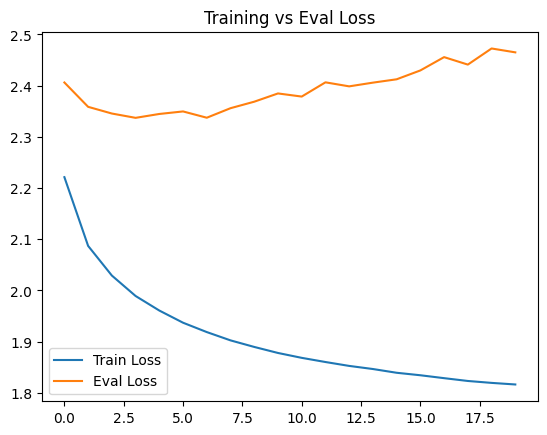

In [31]:
plt.plot(train_losses, label="Train Loss")
plt.plot(eval_losses, label="Eval Loss")
plt.legend()
plt.title("Training vs Eval Loss")
plt.show()

In [32]:
def generate(model, block_size, num_samples=20):
    model.eval()
    for _ in range(num_samples):
        context = [0] * block_size
        out = []

        while True:
            x = torch.tensor([context]).to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()

            context = context[1:] + [ix]
            if ix == 0:
                break
            out.append(itos[ix])

        print("".join(out))


generate(model, block_size)

azarya
jetzel
joshua
tahli
zayra
jaycee
deshua
amarah
darie
takotalyn
rilin
avryn
kiele
kalila
mauin
caspen
skylloud
miaya
adrian
cryth
